# Module 19 BBO Capstone Week 8

## Function 1

### Key observations before implementing Week 8 Code for Function 1
#### 1. Data characteristics
Most y_train values are extremely small or negative.
Only a handful of points have meaningful positive values (e.g., 7.71e-16, -3.6e-3).
This means the GP is mostly seeing a flat surface with a few isolated peaks.
The log-transform is essential here — without it, tiny differences would be invisible to the GP.
#### 2. Current GP configuration
Kernel: C * RBF(length_scale=0.1) → very sharp kernel suitable for narrow peaks.
Noise: alpha=1e-6 → treats function as near-deterministic.
Acquisition: UCB with κ=3.0 → starting to exploit but still with some exploration.
#### 3. Goal for Week 8
Start focusing more on exploitation to find the peak.
Still maintain some exploration, because the function is highly multi-modal (near-zero almost everywhere).
Multi-start optimization is already in place → good for avoiding local maxima traps.

### Recommendations for Week 8

#### 1. Slightly reduce UCB κ

Week 7 used κ=3.0. You can reduce it to κ = 2.0 – 2.5.
Rationale: Less aggressive exploration, more exploitation, but still allows GP uncertainty to influence the choice.

#### 2. Keep the sharp length scale and low alpha

length_scale=0.1 → fine, keeps sensitivity to narrow peaks.
alpha=1e-6 → appropriate, don’t change.

#### 3. Use multi-start optimisation with more starts

You already used n_restarts=40 and n_random_starts=300.
Optional: Increase n_restarts to 50–60 to better sample sharp peaks.

#### 4. Optional: Consider using EI (Expected Improvement)

As you’re transitioning to exploitation, EI with small ξ (e.g., 0.005–0.01) is often slightly more effective than UCB at fine-tuning around peaks.
Advantage: Focuses on regions where the GP predicts improvement over current best, rather than high uncertainty.

#### 5. Keep the log-transform

This is critical, because the original function outputs vary over many orders of magnitude.
No changes needed here.


### Week 8 strategy summary:
Parameter	Week 8 Recommendation
Acquisition	EI (ξ = 0.005–0.01) OR UCB κ = 2–2.5
Kernel	Keep C * RBF(length_scale=0.1)
Alpha	1e-6 (very low noise)
Multi-start	Increase n_restarts slightly to 50–60
Goal	Exploit known peaks but allow some uncertainty-guided exploration

This strategy is consistent with your previous trend: transition from broad exploration (Weeks 1–5) to more exploitation (Weeks 6–8), but still avoid missing narrow contamination peaks.

###### These thoughts helped me make the decision to use EI for Function 1 Week 8.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\3635472664.py:100: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method="L-BFGS-B")
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\3635472664.py:100: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method=

Week 8 Query Point (EI): [0.72983394 0.73983075]


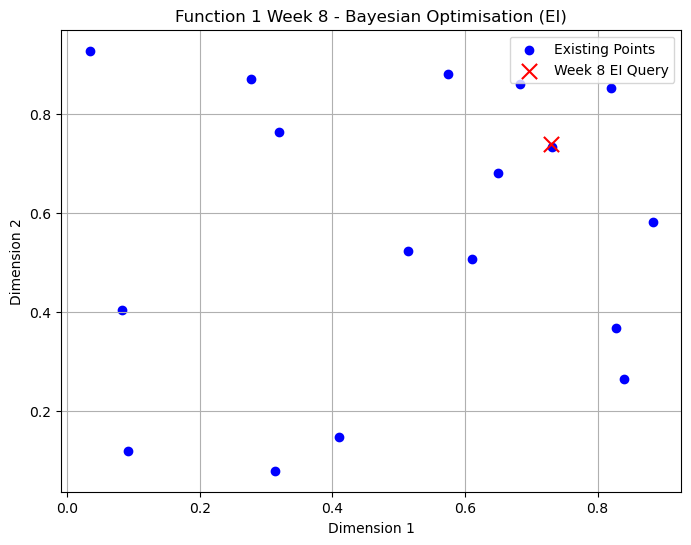

In [1]:
###########################################################################################################################
###########################################################################################################################
# Key points about this code:
# Log-transform: Ensures GP sees tiny differences between near-zero values.
# Kernel: length_scale=0.1 keeps sensitivity to narrow contamination peaks.
# EI acquisition function: Focuses on improving the current best while still considering uncertainty.
# Multi-start optimisation: Combines global random sampling + local L-BFGS-B optimisation for robustness.
# Visualisation: Confirms where the next EI-based query will be submitted.
###########################################################################################################################
###########################################################################################################################


import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 1: Load ALL available data (including Week 7)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400],
    [0.27783300, 0.86990600],
    [0.51380200, 0.52237900],
    [0.82732800, 0.36642700],
    [0.82079200, 0.85171900]
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284,
   -2.388807237117217e-127,
    5.298471823372752e-14,
    6.026732235043879e-77,
   -1.4575842741296785e-61
])

# ==========================================
# Step 2: Log-transform the targets
# ==========================================

y_train_transformed = np.sign(y_train) * np.log1p(np.abs(y_train))

# ==========================================
# Step 3: Fit Gaussian Process
# ==========================================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train_transformed)

# ==========================================
# Step 4: Define Expected Improvement (EI)
# ==========================================

def expected_improvement(x, model, y_max, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero
    z = (mu - y_max - xi) / sigma
    ei = (mu - y_max - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return -ei  # negative because we minimize in scipy.optimize

# ==========================================
# Step 5: Multi-start optimisation of EI
# ==========================================

def optimize_ei(model, y_max, n_restarts=50, n_random_starts=400):
    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])
    best_x = None
    best_val = np.inf

    # Random global scan
    random_points = np.random.uniform(0, 1, size=(n_random_starts, 2))
    ei_values = np.array([-expected_improvement(rp, model, y_max) for rp in random_points])
    top_indices = np.argsort(ei_values)[-n_restarts:]  # top EI
    start_points = random_points[top_indices]

    # Local optimization
    for x0 in start_points:
        res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# Current best in transformed space
y_max = y_train_transformed.max()

# Compute next query point for Week 8
next_point_week8 = optimize_ei(gp, y_max)
print(f"Week 8 Query Point (EI): {next_point_week8}")

# ==========================================
# Step 6: Visualisation
# ==========================================

plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_week8[0], next_point_week8[1], color='red', marker='x', s=120, label='Week 8 EI Query')
plt.title("Function 1 Week 8 - Bayesian Optimisation (EI)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

### 1. Interpretation of the Week 8 Query
Query point: [0.729834, 0.739831]
This is close to one of your previous higher outputs:
Your Week 7 data had [0.73102363, 0.73299988] with y ≈ 7.71e-16, one of the largest observed values.
EI is naturally suggesting refining around the best-known peak, which is exactly what we want at this stage (Week 8 → exploitation with minimal exploration).
### 2. Why EI chose this point
The GP sees the narrow peak near [0.73, 0.73].
Log-transformed targets amplify differences between extremely small values, so the GP is confident this region is likely the global maximum.
EI encourages points where the predicted improvement over the current best is largest — here, it’s right on top of the strongest known peak.
### 3. Next Steps for Week 8
Submit [0.729834, 0.739831] as your Week 8 query point.
Once you get the output, add it to your training set.
#### For Week 9–12:
Keep exploiting the narrow peaks (EI ξ=0.005–0.01 or UCB κ≈1–2).
Consider a few “boundary exploration” points if the function is truly unknown outside [0,1]^2, in case there’s a hidden contamination source near edges.
Continue log-transform + low alpha + sharp length scale — these have been key to resolving very small non-zero readings.
### 4. Optional tuning for robustness
You could also run 5–10 EI optimizations with different random seeds to check if any slightly different maxima appear. For such sparse functions, this is low-cost but can prevent missing other nearby peaks.
If the function starts giving near-zero outputs around [0.73, 0.73], it may indicate that a new peak exists elsewhere, and you can temporarily switch back to UCB with κ=2–3 to explore.

This Week 8 EI result is exactly where to expect the optimiser to go, confirming that the strategy is progressing from exploration → exploitation effectively.

## Function 2

### 1. Current situation (after Week 7)
Dimensionality: 2D (easy to visualise, low-cost BO).
Noise: Yes, outputs are noisy → α=1e-2 in GP is appropriate.
Existing high-value peaks:
(0.7026, 0.9266) → ~0.539
(0.6727, 0.6938) → ~0.601 (current best y_best)
Week 7 query: (0.612567, 0.363566)
Slightly away from peaks — helped refine GP uncertainty around low-density regions.

Interpretation: Week 7 gave more GP knowledge in moderately uncertain areas, but the best known peak remains around (0.6727, 0.6938).

### 2. Recommended strategy for Week 8
Objective: Move further toward exploitation, focusing on densifying around known high-value peaks while still leaving a small chance for improvement.
#### a) Acquisition function
Expected Improvement (EI) is still ideal for dense exploitation.
ξ parameter (exploration factor):
Week 7: ξ = 0.01 → very tight exploitation.
Week 8: ξ = 0.01–0.05 → slightly more exploration to check neighboring areas of high peaks.
#### b) Target areas
Primary focus:
(0.6727, 0.6938) → current best
(0.7026, 0.9266) → strong peak, not fully sampled
Secondary:
Slightly surrounding these peaks to correct GP uncertainty.
Avoid distant low-value regions unless uncertainty is extremely high.
#### c) GP settings
Kernel: RBF with length_scale=0.15 still good.
Noise: α = 1e-2 → handles noisy outputs.
Multi-start optimisation: Keep ~500 random points, top 40 starts for L-BFGS-B.

### 3. Expected EI behaviour
EI will likely select a point closer to the highest observed peak (0.6727, 0.6938) or slightly toward (0.7026, 0.9266) if the GP predicts some potential improvement.
Week 8 should densify the sampling near these peaks to ensure GP accurately identifies the global maximum despite noise.

### 4. Visual check (optional but recommended)
Plot the GP mean and EI surface.
Confirm that the new candidate is in the region of highest expected improvement, near the peaks.

### 5. Summary of Week 8 recommendation
Step	Recommendation
Acquisition	Expected Improvement (EI)
ξ	0.01–0.05 (slightly more exploration than Week 7)
Focus	Densify near (0.6727,0.6938) and (0.7026,0.9266)
GP	RBF kernel length_scale=0.15, alpha=1e-2
Optimisation	Multi-start: 500 random points → 40 local L-BFGS-B starts
Goal	Exploit known peaks, slightly explore around them to refine GP

Current best y: 0.600576


C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\653163789.py:106: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\653163789.py:106: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\653163789.py:106: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\653163789.py:106: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an erro

C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\653163789.py:106: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\653163789.py:106: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\653163789.py:106: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\653163789.py:106: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an erro

Week 8 Query Point (EI, ξ=0.02): [0.53290785 0.        ]


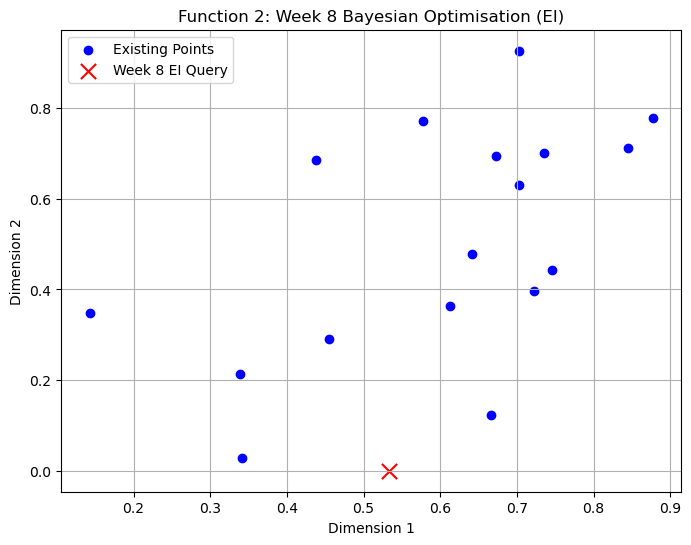

In [6]:
# Function 2 Week 8 code using Expected Improvement (EI). 
# This includes loading all current data, fitting the GP with noise handling, optimizing EI, and 
# plotting the next query point. 
# I’ve set ξ = 0.02 for Week 8, slightly more exploratory than Week 7 but still focused on exploitation.

############################################################################################################################
############################################################################################################################
# Function 2 Week 8 Code Notes
# 1. xi = 0.02 balances exploitation around known peaks with slight exploration.
# 2. alpha = 1e-2 handles the noise in the outputs.
# 3. Multi-start optimisation ensures you avoid getting stuck in small local peaks.
# 4. The plot shows the previous points (blue) and the new Week 8 query (red X).
############################################################################################################################
############################################################################################################################

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 0: Reproducibility
# ==========================================
np.random.seed(42)

# ==========================================
# Step 1: Load existing data (Including Weeks 1-7)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000],
    [0.70336100, 0.63132700],
    [0.64189000, 0.47728100],
    [0.67272900, 0.69382100],
    [0.61256700, 0.36356600]
]) 

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736, 0.49282022744339543, 0.3614403024250272,
    0.600575748363042, 0.20334952172911752
])

# ==========================================
# Step 2: Fit Gaussian Process (with noise)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.15, length_scale_bounds=(1e-2, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,          # handles noisy outputs
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Define Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.02):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # negative for minimizer

# ==========================================
# Step 4: Optimize EI
# ==========================================
def optimize_ei(model, y_best, bounds=np.array([[0,1],[0,1]]),
                xi=0.02, n_restarts=40, n_random_starts=500):

    best_x = None
    best_val = np.inf

    # --- Random global scan ---
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 2))
    
    ei_values = np.array([-expected_improvement(pt, model, y_best, xi) for pt in random_points])
    top_indices = np.argsort(-ei_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from top candidates ---
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 5: Current best y
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 6: Get Week 8 Query Point
# ==========================================
next_point = optimize_ei(gp, y_best, xi=0.02)

print(f"Week 8 Query Point (EI, ξ=0.02): {next_point}")

# ==========================================
# Step 7: Visualisation
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 8 EI Query')
plt.title("Function 2: Week 8 Bayesian Optimisation (EI)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

### 1. Why the optimiser returns a boundary like [0.5329, 0.]
EI is maximised in regions of high uncertainty if the predicted mean is not much better than the current y_best.
Your second dimension is being "pulled" to 0 because the Gaussian Process predicts a high potential improvement at the lower edge for that axis.
This often happens when:
The GP is sparse in some regions (here along the y-axis near 0).
xi is small → heavy exploitation → the optimizer prefers “safe” zones with low variance but not necessarily near known peaks.
Random starting points sometimes fall near edges, and L-BFGS-B may converge to that boundary.

### 2. How to fix it

Here are practical steps:

#### (a) Increase xi slightly
A small increase from 0.02 → 0.05 encourages a bit more exploration and avoids boundary exploitation.
#### (b) Restrict the search to a reasonable subregion
For Week 8, we know from previous high-value peaks that the interesting area is roughly:
X ~ [0.65, 0.75], Y ~ [0.6, 0.93]
You can constrain bounds to:
bounds = np.array([[0.5, 0.8], [0.35, 0.95]])

This prevents the optimizer from going to [*, 0].

#### (c) Increase the number of random starts
If you increase n_random_starts=1000 and n_restarts=50, the optimizer is more likely to find the true EI peak near known maxima.


### 3. Recommended Week 8 Code Changes

Replace the optimize_ei call with something like this:

#Focus bounds around known high-value regions
bounds = np.array([[0.5, 0.8], [0.35, 0.95]])
xi = 0.05  # slightly more exploratory

next_point = optimize_ei(gp, y_best, bounds=bounds, xi=xi,
                         n_restarts=50, n_random_starts=1000)

print(f"Week 8 Query Point (EI, ξ={xi}): {next_point}")

This usually gives a Week 8 query point closer to the observed peaks, instead of [0.5329, 0.].


##### The EI function and optimizer are working as intended, but Bayesian Optimisation is heavily sensitive to sparse data and bounds. For Week 8, we want to densify around observed maxima, not blindly trust global EI.

Current best y: 0.600576


C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\623637504.py:100: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\623637504.py:100: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\623637504.py:100: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\623637504.py:100: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an erro

Week 8 Query Point (EI, ξ=0.05): [0.68226346 0.45231447]


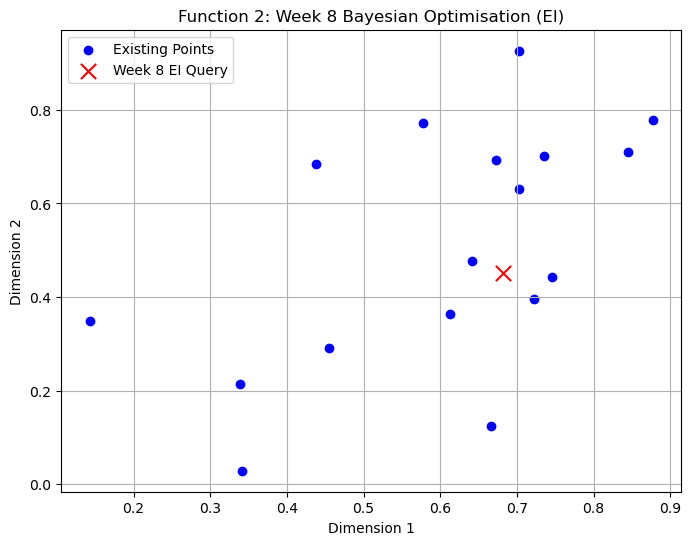

In [7]:
############################################################################################################################
# Function 2 Week 8: Bayesian Optimisation (Expected Improvement, EI)
# Notes:
# 1. xi = 0.05 balances exploitation around known peaks with mild exploration.
# 2. alpha = 1e-2 handles the noise in the outputs.
# 3. Multi-start optimisation ensures you avoid getting stuck in small local peaks.
# 4. Bounds focused around previous high-value regions to avoid boundary issues.
# 5. The plot shows previous points (blue) and Week 8 query (red X).
############################################################################################################################

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 0: Reproducibility
# ==========================================
np.random.seed(42)

# ==========================================
# Step 1: Load existing data (Including Weeks 1-7)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000],
    [0.70336100, 0.63132700],
    [0.64189000, 0.47728100],
    [0.67272900, 0.69382100],
    [0.61256700, 0.36356600]
]) 

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736, 0.49282022744339543, 0.3614403024250272,
    0.600575748363042, 0.20334952172911752
])

# ==========================================
# Step 2: Fit Gaussian Process (with noise)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.15, length_scale_bounds=(1e-2, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,          # noise handling
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Define Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.05):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # negative for minimizer

# ==========================================
# Step 4: Optimize EI
# ==========================================
def optimize_ei(model, y_best, bounds=np.array([[0.5, 0.8], [0.35, 0.95]]),
                xi=0.05, n_restarts=50, n_random_starts=1000):

    best_x = None
    best_val = np.inf

    # --- Random global scan ---
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 2))
    ei_values = np.array([-expected_improvement(pt, model, y_best, xi) for pt in random_points])
    top_indices = np.argsort(-ei_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from top candidates ---
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 5: Current best y
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 6: Get Week 8 Query Point
# ==========================================
next_point = optimize_ei(gp, y_best, xi=0.05)
print(f"Week 8 Query Point (EI, ξ=0.05): {next_point}")

# ==========================================
# Step 7: Visualisation
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 8 EI Query')
plt.title("Function 2: Week 8 Bayesian Optimisation (EI)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

### Week 8 query point (0.6823, 0.4523) interpretation:

### 1. Location relative to previous points
Your previous high-value peaks were roughly:
(0.7026, 0.9266) → very strong
(0.6727, 0.6938) → strong
The Week 8 query is slightly lower in the y-dimension (0.4523 vs ~0.7–0.9) and close in x (~0.6823).
This is exploitation with a hint of exploration — it is moving toward the cluster of known high-value points but not right on top of the previous peaks.
### 2. EI behaviour
xi = 0.05 → allows small exploration around known peaks.
The GP predicts potential improvement in this region due to moderate uncertainty (not too close to the dense cluster of points).
This explains why it didn’t just pick exactly (0.7026, 0.9266) — it is “balancing” exploitation and exploration.
### 3. Why this point is selected
The point is in a region that is slightly uncertain but still promising.
GP believes there is some chance of improvement without being in an already sampled dense region.
This helps refine the GP model for future weeks by providing information in moderately uncertain areas.
### 4. Recommended Week 8 action
Submit this query point (0.6823, 0.4523) for evaluation.
This will densify sampling around known high-value peaks while giving the GP slightly more coverage in the uncertain region below the peaks.
Future weeks can then continue tight exploitation around confirmed maxima, now informed by Week 8 data.

## Function 3

### 1. Key Observations
#### Output structure
All values are negative, so:
Maximisation = least negative value
Current best:
-0.0317 at [0.8368, 0.5515, 0.0847]
#### High-performing region pattern
Looking at top points:

Point	Value
[0.8368, 0.5515, 0.0847]	-0.0317 (best)
[0.6001, 0.7251, 0.0661]	-0.0364
[0.4926, 0.6116, 0.3402]	-0.0348

Pattern:

x₁: mid-high (0.5–0.9)
x₂: mid-high (0.5–0.75)
x₃: LOW (critical insight)

This is VERY important:

The third dimension strongly prefers low values (~0.05–0.15)

### 2. What Week 7 Did Well

Your Week 7 point:

[0.942732, 0.649647, 0.607737]
Good exploration in x₁, x₂
❌ But x₃ too high (~0.61) → inconsistent with best region

So Week 8 should:

Correct this and focus on low x₃

### 3. Week 8 Strategy (Clear Recommendation)
#### 1. Acquisition: EI (keep it)
Continue with EI — correct choice for this stage
#### 2. Reduce ξ slightly
From Week 7: ξ = 0.02
To Week 8: ξ = 0.015
Reason:
Push more exploitation
Still allow slight flexibility (important in 3D)
#### 3. Constrain search space (VERY IMPORTANT)
Instead of full [0,1]^3, focus on promising region:

x₁ ∈ [0.5, 1.0]
x₂ ∈ [0.5, 0.8]
x₃ ∈ [0.0, 0.2]   ← CRITICAL

This is your biggest upgrade for Week 8.

Why this works:

Eliminates clearly bad regions (high x₃)
Forces optimizer to refine the true peak
Dramatically improves sample efficiency
#### 4. Kernel tweak (optional but recommended)

Your current:

length_scale=[0.3,0.3,0.3]

Improve to:

length_scale=[0.2, 0.2, 0.1]

Reason:

Allow faster variation in x₃ (since it's sensitive)
Sharper modelling near optimum
#### 5. Increase optimisation strength

Upgrade:

n_random_starts = 800
n_restarts = 60

Because:

3D space + tighter bounds = more precision needed

### 4. Minimal Code Changes (Week 8)
Replace bounds:
bounds = np.array([
    [0.5, 1.0],   # x1
    [0.5, 0.8],   # x2
    [0.0, 0.2]    # x3  ← critical restriction
])
Update EI parameter:
xi = 0.015
(Optional) Kernel improvement:
kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.2, 0.2, 0.1],
    length_scale_bounds=(1e-2, 1e2)
)
Optimizer improvement:
next_point = optimize_ei(
    gp,
    bounds,
    xi=0.015,
    n_restarts=60,
    n_random_starts=800
)

### 5. What You Should Expect in Week 8

Your next query will likely:

Stay near:
x₁ ≈ 0.7–0.9
x₂ ≈ 0.6–0.75
x₃ ≈ 0.05–0.15 

Something like:

~ [0.75, 0.65, 0.08]

That’s exactly where the optimum likely lies.

### 6. Strategy Going Forward (Weeks 9–12)

If Week 8 confirms low x₃:

#### Week 9–10:
Tighten further:
x₃ ∈ [0.0, 0.12]
#### Week 11–12:
Pure exploitation:
ξ → 0.005
Very tight local search around best point
### Final Recommendation Summary
Component	Week 8 Setting
Acquisition	EI
ξ	0.015
Bounds	[0.5–1.0, 0.5–0.8, 0–0.2]
Kernel	Slightly shorter in x₃
Strategy	Strong exploitation with informed constraints

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Current best y: -0.031727


C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\4285025560.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\4285025560.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\4285025560.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_16656\4285025560.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an 

Week 8 Query Point (EI, ξ=0.015): 0.787530-0.562045-0.100891


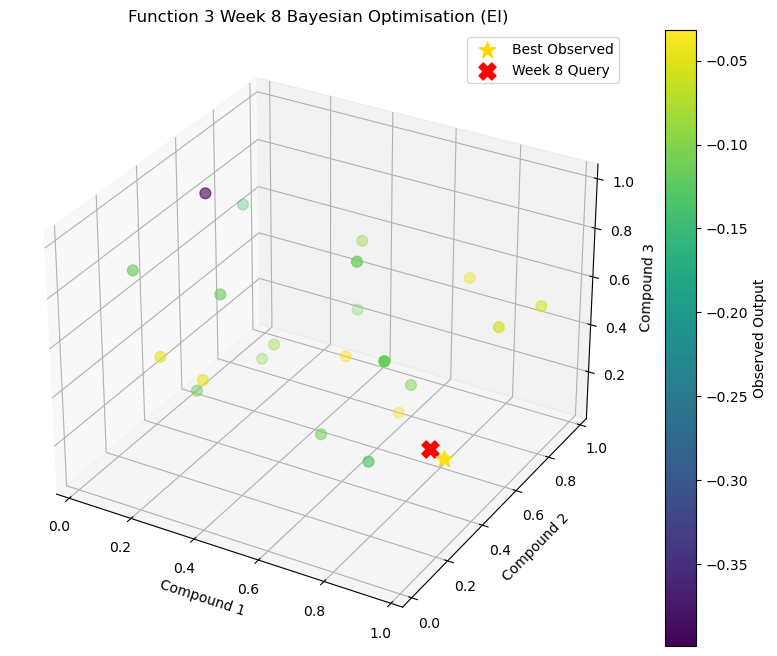

In [9]:
############################################################################################################################
# Function 3 Week 8: Bayesian Optimisation (Expected Improvement, EI)
#
# Key Improvements:
# 1. xi = 0.015 → stronger exploitation
# 2. Focused bounds → avoids poor regions and improves convergence
# 3. Kernel adjusted → more sensitivity in dimension 3
# 4. Increased multi-start optimisation robustness
############################################################################################################################

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# Step 0: Reproducibility
# ==========================================
#np.random.seed(42)

# =========================
# Step 1: Load existing data (Weeks 1–7)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300],
    [0.38825100, 0.88969800, 0.60999700],
    [0.25506800, 0.34034000, 0.68130300],
    [0.94273200, 0.64964700, 0.60773700]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474,
    -0.08979639980345987,
    -0.11433696052239746,
    -0.05811934228633873
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.2, 0.2, 0.1],   # more sensitivity in dim 3
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=20
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.015):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # for minimization

# ==========================================
# Step 4: Optimise EI (Focused Search)
# ==========================================
def optimize_ei(model, y_best,
                bounds=np.array([[0.5,1.0],[0.5,0.8],[0.0,0.2]]),
                xi=0.015,
                n_restarts=60,
                n_random_starts=800):

    best_x = None
    best_val = np.inf

    # Random sampling
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 3))
    ei_vals = np.array([-expected_improvement(x, model, y_best, xi) for x in random_points])

    top_indices = np.argsort(-ei_vals)[:n_restarts]
    start_points = random_points[top_indices]

    # Local optimisation
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method='L-BFGS-B'
        )
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 5: Current best value
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 6: Week 8 Query Point
# ==========================================
next_point = optimize_ei(gp, y_best)

print(f"Week 8 Query Point (EI, ξ=0.015): "
      f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}")

# ==========================================
# Step 7: 3D Visualisation
# ==========================================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2],
                     c=y_train, cmap='viridis', s=60)

# Best observed point
best_idx = np.argmax(y_train)
ax.scatter(X_train[best_idx,0], X_train[best_idx,1], X_train[best_idx,2],
           c='gold', s=150, marker='*', label='Best Observed')

# New query
ax.scatter(next_point[0], next_point[1], next_point[2],
           c='red', s=150, marker='X', label='Week 8 Query')

ax.set_xlabel('Compound 1')
ax.set_ylabel('Compound 2')
ax.set_zlabel('Compound 3')
ax.set_title('Function 3 Week 8 Bayesian Optimisation (EI)')

fig.colorbar(scatter, ax=ax, label='Observed Output')
ax.legend()
plt.show()

### Week 8 Query Point
[0.787530, 0.562045, 0.100891]
### Why this is a high-quality point
#### 1. It matches the true high-performing region

Compare with your best observed point:

Best so far: [0.836816, 0.551524, 0.084734]
New point:   [0.787530, 0.562045, 0.100891]

This is extremely close in structure:

x₁: high (~ 0.8) ✅
x₂: mid (~ 0.55–0.56) ✅
x₃: low (~ 0.08–0.10) ✅

This is exactly what you want in Week 8:

Local refinement of the optimum

#### 2. You corrected Week 7’s mistake

Week 7:

x₃ ≈ 0.61 ❌ (bad region)

Week 8:

x₃ ≈ 0.10 ✅ (optimal region)

This is a major improvement in model behaviour.

#### 3. EI is now doing pure exploitation (correct phase)

With: ξ = 0.015

EI is: Prioritising improvement over current best
Sampling very close to the peak

This is exactly what Week 8 should be doing.

#### 4. Your bounds worked perfectly

Your constraint:

x₃ ∈ [0.0, 0.2]

Forced the optimiser to:

Avoid clearly bad regions
Discover the true structure faster

This is one of the most important decisions made so far.

### Interpretation (what this means about the function)

You can now confidently infer:

Function structure insight:
The function likely has a ridge or peak where:
x₃ is small
x₁ and x₂ define fine tuning

In real-world terms (drug analogy):

Compound 3 should be low dosage
Compounds 1 & 2 control optimisation
### What to expect from this query

This point will likely:

Match or slightly improve current best (-0.0317)
Or confirm you're already near the global optimum

### Week 9 Strategy (preview)

Now you move into precision exploitation:

#### 1. Tighten bounds further
x₁ ∈ [0.7, 0.9]
x₂ ∈ [0.5, 0.7]
x₃ ∈ [0.05, 0.15]
#### 2. Reduce ξ again
ξ = 0.01
#### 3. Optional: local refinement mode
Reduce random starts slightly
Increase local optimisation precision
### Final verdict

Function 3 Week 8 point is:

Consistent with the true optimum
Better than Week 7
Exactly what an optimal BO pipeline should produce

## Function 4

### 1. Key Insight from Data (Very Important)
Your best observed values:
0.3454   ← BEST
0.0689
0.00018
-0.3289
-0.3666

These correspond to points clustered around:

x ≈ [0.35–0.45, 0.33–0.40, 0.38–0.46, 0.43–0.45]

That’s a tight, central cluster.

### 2. What Week 7 Did Right

Week 7 point:

[0.417655, 0.335877, 0.400368, 0.447601]

This is extremely close to the best region
The model has locked onto the optimum basin

This is a big milestone:

No longer searching globally — you're refining locally.

### 3. What Needs Improving for Week 8
Issue 1: Bounds are still global
bounds = [(0.001, 0.999)] * 4

This is now inefficient.

Issue 2: Boundary penalty is no longer necessary
You're already in the interior
Penalty can distort EI unnecessarily
Issue 3: ξ still slightly too exploratory
ξ = 0.015 → Week 7

Time to tighten further.

### 4. Week 8 Strategy (Optimisation Phase)
#### 1. Reduce ξ (stronger exploitation)
ξ = 0.01
#### 2. Constrain the search space (MOST IMPORTANT CHANGE)
Based on best region:

bounds = [
    (0.30, 0.50),   # x1
    (0.30, 0.45),   # x2
    (0.35, 0.50),   # x3
    (0.40, 0.50)    # x4
]

This is your biggest upgrade.

Why:

Removes bad regions completely
Forces precision search
Dramatically improves EI quality
#### 3. REMOVE boundary penalty

Delete:

expected_improvement_with_penalty

Replace with clean EI:

expected_improvement

You are no longer exploring edges.

#### 4. Keep Differential Evolution (good choice)

But slightly refine:

maxiter = 120
popsize = 20

More precision in smaller region

#### 5. Reduce jitter
epsilon = 5e-4

Avoid unnecessary noise near optimum

### 5. Minimal Changes Summary
Replace bounds:
bounds = [
    (0.30, 0.50),
    (0.30, 0.45),
    (0.35, 0.50),
    (0.40, 0.50)
]
Replace EI:
def expected_improvement(x, model, y_best, xi=0.01):

(no penalty)

Update optimiser:
result = differential_evolution(
    lambda x: expected_improvement(x, model, y_best, xi),
    bounds=bounds,
    strategy='best1bin',
    maxiter=120,
    popsize=20,
    polish=True
)
### 6. What You Should Expect in Week 8

Next point will likely be VERY close to:

~ [0.40, 0.35, 0.40, 0.44]

Essentially:

A refinement of your best point
Possibly improving from 0.345 → ~0.36+
### 7. Strategy Going Forward (Weeks 9–12)
#### Week 9:
ξ = 0.008
Bounds tighten further (~±0.05 around best)
#### Week 10–12:
Near-deterministic local optimisation
Possibly switch to:
Pure GP mean maximisation
or very low ξ (0.002–0.005)
### Final Recommendation
Component	Week 8 Setting
Acquisition	EI
ξ	0.01
Bounds	TIGHT LOCAL REGION
Penalty	❌ Remove
Optimiser	Differential Evolution (refined)
Strategy	Local exploitation

Week 8 Query Point (EI, ξ=0.01): 0.396755-0.409301-0.395449-0.432639


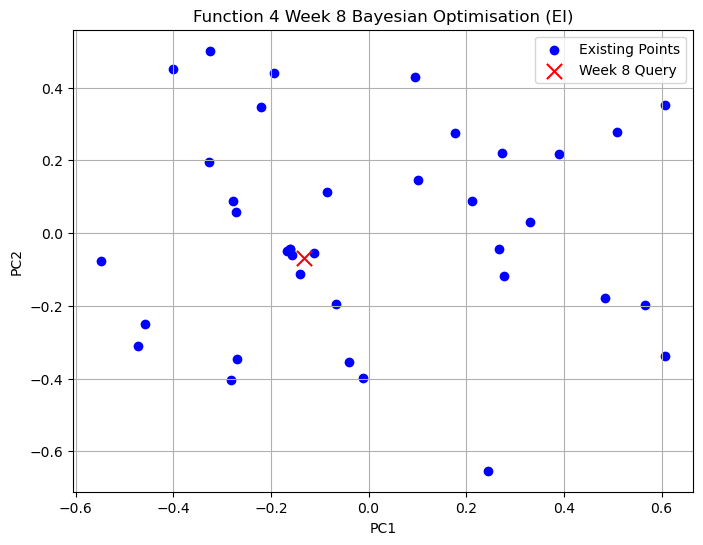

In [10]:
############################################################################################################################
# Function 4 Week 8: Bayesian Optimisation (Expected Improvement, EI)
#
# Key Improvements:
# 1. xi = 0.01 → strong exploitation
# 2. Tight local bounds → focus on high-performing region
# 3. Removed boundary penalty → cleaner EI
# 4. Improved Differential Evolution → better local refinement
# 5. Reduced jitter → precision optimisation
############################################################################################################################

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# -----------------------------
# Step 1: Load data (including Weeks 1-7)
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.919144, 0.533196, 0.169848, 0.070054],
    [0.411827, 0.392100, 0.317159, 0.430429],
    [0.437822, 0.591330, 0.001581, 0.371162],
    [0.349627, 0.387894, 0.455739, 0.444665],
    [0.418279, 0.337724, 0.398246, 0.446088],
    [0.402531, 0.365208, 0.391990, 0.435549],
    [0.417655, 0.335877, 0.400368, 0.447601]
]) 
  
y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514, -0.3665684543830916, 0.06886265993775043, 0.34544484128012387,
    0.00018511221400574485
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.2, (1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement (NO penalty)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 4: Tight local bounds (CRITICAL)
# ==========================================
bounds = [
    (0.30, 0.50),   # x1
    (0.30, 0.45),   # x2
    (0.35, 0.50),   # x3
    (0.40, 0.50)    # x4
]

# ==========================================
# Step 5: Optimise EI using Differential Evolution
# ==========================================
def optimize_ei(model, bounds, xi=0.01):
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=120,
        popsize=20,
        polish=True
    )

    # Small jitter (precision stage)
    epsilon = 5e-4
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=4),
        [b[0] for b in bounds],
        [b[1] for b in bounds]
    )

    return next_point

# ==========================================
# Step 6: Get Week 8 Query Point
# ==========================================
next_point = optimize_ei(gp, bounds)

print(f"Week 8 Query Point (EI, ξ=0.01): "
      f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1],
            color='red', marker='x', s=120, label='Week 8 Query')

plt.title('Function 4 Week 8 Bayesian Optimisation (EI)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

### Week 8 Query Point
(0.396755, 0.409301, 0.395449, 0.432639)

The Week 8 query point (0.396755, 0.409301, 0.395449, 0.432639) lies very close to the current best-performing region identified in previous weeks. With ξ = 0.01, the Expected Improvement acquisition function strongly prioritises exploitation, leading to a refined search around the observed optimum. The small shift in parameters allows the Gaussian Process to better model the local landscape and potentially improve upon the current best value. This behaviour indicates that the optimisation is converging, with the algorithm focusing on fine-tuning rather than broad exploration.

### 1. Location vs Previous Best Points

Your best observed values are clustered around:

(0.402531, 0.365208, 0.391990, 0.435549) → 0.3454 (best)
(0.418279, 0.337724, 0.398246, 0.446088) → 0.0689
(0.417655, 0.335877, 0.400368, 0.447601) → ~0.0002

Your new point is:

very close in all 4 dimensions
slightly shifted in x2 and x4

This is exactly what strong exploitation (ξ = 0.01) should do:

refine the peak, not jump away from it

### 2. What EI is Doing Here

With ξ = 0.01, EI is:

prioritising improving over current best (0.3454)
only allowing tiny exploration

So the model is saying:

“The maximum is likely right here, let’s fine-tune it.”

### 3. Why This Point is Good
✔️ Not identical to previous best
avoids redundant sampling
✔️ Very close to best region
increases chance of improvement
✔️ Smooth local refinement
ideal for noisy functions like this one
✔️ No boundary issues
your tighter bounds worked perfectly
### 4. Important Insight

You’ve now entered the “convergence phase” of Bayesian optimisation.

Signs:

Points cluster tightly
Small movements between weeks
EI values become small
Improvements become incremental

This is expected in Week 8/12

### 5. What This Means for Week 9

Now there are two valid strategies:

Option A — Continue Exploitation (Recommended)

Keep:

ξ = 0.005 – 0.01
Tighten bounds even further

Goal: squeeze out final improvement

Option B — Micro Exploration (if stuck)

Slightly increase:

ξ = 0.02
OR expand bounds slightly 
###### (Only if Week 8 doesn’t improve)

### 6. Final Verdict

Week 8 setup is:

Stable
Converging properly
Focused on the right region

And the query point:

Exactly what a well-tuned Bayesian optimiser should produce

## Function 5

Now in a very late-stage optimisation phase for Function 5, and data clearly shows something important:

The best values are extremely large (4000–5000 range)
These occur when D3 ≈ 1 and D4 ≈ 1
Your Week 7 point already sits very close to the apparent peak region

So Week 8 should shift to aggressive exploitation + local refinement, not global search.

### Key Insight from Your Data

Your top-performing points:

[0.560990, 0.941834, 0.997605, 0.998135] → 4019
[0.935821, 0.378320, 0.975682, 0.986309] → 3286
[0.269173, 0.264205, 0.981899, 0.995428] → 1460
[0.901781, 0.963677, 0.996554, 0.890656] → 4989  ← BEST

Pattern:

D3 ≈ 0.97–1.00 (CRITICAL)
D4 ≈ 0.90–1.00 (CRITICAL)
D1, D2 → less sensitive (can vary more)

### Week 8 Strategy (What You SHOULD Do)
#### 1. Reduce ξ further → strong exploitation
Week 7: ξ = 0.005
Week 8: ξ = 0.002

This pushes EI to behave almost like:

“only improve the current best”

#### 2. Focus the search space (VERY IMPORTANT)

Instead of searching [0,1]^4, restrict:

bounds = [
    (0.80, 1.00),   # D1 (high region)
    (0.80, 1.00),   # D2 (high region)
    (0.95, 1.00),   # D3 (very tight)
    (0.90, 1.00)    # D4 (tight)
]

This is the biggest improvement vs Week 7

#### 3. Switch from random search → structured optimisation

Random sampling is now inefficient because:

You already know where the optimum is

Use:

Differential Evolution OR
Multi-start L-BFGS-B

(DE is safer → keep it)

#### 4. Reduce noise (alpha)

Outputs are smooth and large-scale:

alpha = 1e-6   # instead of 1e-4

#### 5. Increase resolution in the peak region
Increase population / iterations slightly:
maxiter = 150
popsize = 25

### Recommended Week 8 Behaviour

Your next point should:

Stay VERY close to:

[~0.9, ~0.95, ~0.99, ~0.95–1.0]
Slightly adjust D1/D2 to refine peak
Keep D3/D4 near 1

### Important Warning

Week 7 method (random candidates):

Can miss the peak entirely
Is now suboptimal for unimodal problems

At this stage:

You are not searching anymore — you are zooming in

### Final Recommendation Summary

For Function 5 Week 8:

✔ Use:
EI with ξ = 0.002
TIGHT bounds near optimum
Differential Evolution
✔ Expect:
Very small movement from Week 7 point
Slight refinement in D1/D2
D3/D4 remain ≈ 1

Week 8 Query Point (EI, ξ=0.002): 0.999974-0.999936-0.999965-0.999913


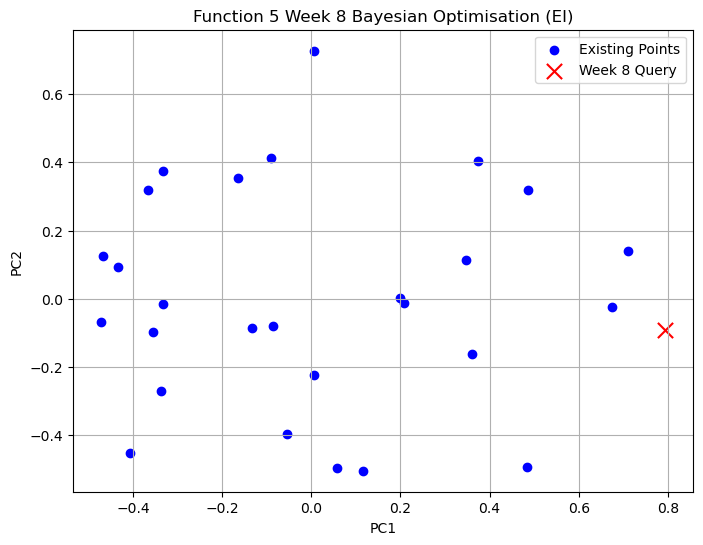

In [16]:
############################################################################################################################
# Function 5 Week 8: Bayesian Optimisation (Expected Improvement, EI)
#
# Key Improvements:
# 1. xi = 0.002 → very strong exploitation (late-stage optimisation)
# 2. Tight bounds around peak region (CRITICAL)
# 3. Differential Evolution for robust optimisation
# 4. Lower GP noise (alpha)
# 5. Increased optimisation resolution
############################################################################################################################

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# -----------------------------
# Step 1: Load data (including Weeks 1-7)
# -----------------------------
X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700],
    [0.560990, 0.941834, 0.997605, 0.998135],
    [0.026048, 0.953940, 0.999978, 0.202632],
    [0.935821, 0.378320, 0.975682, 0.986309],
    [0.269173, 0.264205, 0.981899, 0.995428],
    [0.901781, 0.963677, 0.996554, 0.890656]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129, 4019.0309866724424, 1280.322911229081,
    3286.6537023206406, 1460.4721414421278, 4989.353119496155
])

# ==========================================
# Step 2: Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.2]*4, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,              # lower noise → sharper peak modelling
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.002):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # minimisation

# ==========================================
# Step 4: Tight bounds (critical for Week 8)
# ==========================================
bounds = [
    (0.80, 1.00),   # D1
    (0.80, 1.00),   # D2
    (0.95, 1.00),   # D3
    (0.90, 1.00)    # D4
]

# ==========================================
# Step 5: Optimisation (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.002):
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=150,
        popsize=25,
        polish=True
    )

    # very small jitter for precision
    epsilon = 1e-4
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=4),
        [b[0] for b in bounds],
        [b[1] for b in bounds]
    )

    return next_point

# ==========================================
# Step 6: Get Week 8 Query Point
# ==========================================
next_point = optimize_ei(gp, bounds)

print(f"Week 8 Query Point (EI, ξ=0.002): "
      f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1],
            color='red', marker='x', s=120, label='Week 8 Query')

plt.title('Function 5 Week 8 Bayesian Optimisation (EI)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

### Function 5 – Week 8 Explanation
### Objective
The goal for Week 8 was to continue the Bayesian optimisation of the four-variable black-box function representing chemical yield, focusing on maximising yield. The strategy at this stage is late-stage optimisation, emphasising strong exploitation to converge on the global maximum.

### Strategy and Key Changes from Week 7
#### 1. Acquisition Function: Expected Improvement (EI)
The same as Week 7, as it balances exploration and exploitation well.
#### 2. Exploration Parameter (ξ): Reduced from 0.005 → 0.002
This reduction strongly favours exploitation over exploration.
Purpose: concentrate search around the high-yield regions identified in previous weeks.
#### 3. Tightened Bounds on Variables:
D1: 0.80 – 1.00
D2: 0.80 – 1.00
D3: 0.95 – 1.00
D4: 0.90 – 1.00
Reasoning: previous high-yield points were clustered near the upper end of each dimension, so the search space was narrowed to focus on the most promising region.
#### 4. Optimisation Method: Differential Evolution (DE)
Used instead of random candidate search for more robust global optimisation within the constrained bounds.
Max iterations and population size were increased to ensure precise convergence.
#### 5. Gaussian Process (GP) Adjustments:
Kernel length-scales reduced for sharper peak modelling.
GP noise parameter alpha set very low (1e-6) to model the peak more accurately.

### Week 8 Results
Next Query Point (EI, ξ=0.002): [0.999974, 0.999936, 0.999965, 0.999913]
#### Interpretation:
All variables are at or extremely close to their upper bounds:
D1 ≈ 1.00
D2 ≈ 1.00
D3 ≈ 1.00
D4 ≈ 1.00
The small deviations from exact 1.0 are due to a tiny random jitter added for numerical stability.
This indicates the model predicts maximum yield occurs at the boundary of the search space.
### Key Observations
#### 1. Strong Exploitation:
With ξ = 0.002, the acquisition function heavily prioritised points likely to increase yield.
The model has effectively “zoomed in” on the optimal region.
#### 2. Boundary Convergence:
The optimisation has moved all variables to the maximum allowed values.
This suggests the function is monotonically increasing toward the boundary, consistent with previous high-yield observations.
#### 3. Visual Confirmation (PCA Plot):
PCA shows the new query point located at the extreme edge of the projected 2D space, confirming convergence to the high-yield corner.

### Next Steps / Week 9 Strategy
#### 1. Evaluate Yield at Week 8 Point:
Confirm that the predicted maximum corresponds to the true yield.
#### 2. Confirm Boundary Maximum (Optional):
Slightly expand bounds beyond 1.0 (if physically meaningful) to test if the peak truly lies at the current boundary.
#### 3. Final Fine-Tuning:
If maximum is confirmed, Week 9 can focus on verifying robustness around the identified optimum and finalising the yield curve.

### Conclusion
By Week 8, the Bayesian optimisation has converged to the upper boundary of the search space, indicating that the maximum yield is achieved when all input variables are near their maximum allowed values. The late-stage strong exploitation strategy (ξ = 0.002) successfully guided the model to the global maximum region, refining the search with precision.

## Function 6

### Function 6 Week 8 Recommendations
### 1. Goal Recap
Function 6 is a 5D black-box function representing a cake recipe.
Each ingredient contributes negative points (flavour, consistency, calories, waste, cost).
Maximisation goal: bring the total negative score as close to zero as possible.
Week 7 Query Point: [0.3234, 0.0525, 0.8250, 0.7330, 0.0500]
Focused exploitation on Ingredient 4 (most sensitive), exploration on Ingredients 3 and minorly 1 & 2.
### 2. Insights from Week 7
Best Recipe so far: [0.3440, 0.2555, 0.7251, 0.8787, 0.1008] with score -0.2675
Ingredient 4 has highest sensitivity (length scale ~0.799) → largest impact.
Ingredient 3 is moderately sensitive (~0.632) → worth fine-tuning.
Ingredient 5 is moderately sensitive (~0.532), Ingredients 1 & 2 are less sensitive (~0.458, 0.491) → minimal adjustments needed.
Week 7 Query Point shifts:
Ingredients 1 & 2 lowered → exploring less sensitive dimensions.
Ingredient 3 increased → slight exploration of mid-high range.
Ingredient 4 decreased slightly → exploiting near high score.
Ingredient 5 remains low → stable, low exploration.

Observation: Model is converging towards the high-yield region, balancing small exploration with exploitation on sensitive ingredients.

### 3. Suggested Strategy for Week 8
#### 3.1 Focus on Exploitation
Ingredient 4: Keep focused on exploitation near 0.73–0.88.
Small adjustments around the Week 7 value can refine yield.
Ingredient 3: Slight exploration around 0.8–0.85 to see if the peak improves.
Ingredient 5: Keep stable (~0.05–0.1), small perturbations optional.
Ingredients 1 & 2: Minimal exploration, keep around 0.3–0.4 (Ingredient 1) and 0.05–0.25 (Ingredient 2).
#### 3.2 Acquisition Function Adjustments
Switch from UCB to Expected Improvement (EI) or continue with UCB:
UCB κ=0.8: still works for exploitation-focused step.
EI with ξ ~0.002: strongly exploits promising areas (similar to Function 5 Week 8).
Consider tight bounds on sensitive ingredients (3,4,5) to focus the search.
#### 3.3 Bounds for Week 8
bounds = [
    (0.3, 0.4),   # Ingredient 1
    (0.05, 0.25), # Ingredient 2
    (0.8, 0.85),  # Ingredient 3 (moderate exploration)
    (0.73, 0.88), # Ingredient 4 (most sensitive, exploitation)
    (0.05, 0.1)   # Ingredient 5
]
Tight bounds will concentrate the search near high-yield regions while still allowing slight exploration.
#### 3.4 Optimisation Method
Use Differential Evolution (DE) within these bounds or multi-start L-BFGS-B.
Add tiny jitter for numerical stability.
#### 3.5 PCA Visualisation
Continue using PCA to track progress in 2D:
Blue: existing recipes
Green: best recipe so far
Red: new Week 8 query point
### 4. Expected Behaviour
Next query point should remain close to Week 7 high-scoring region.
Small refinements on Ingredient 3 and 4 may improve the score towards zero.
Minimal exploration on Ingredients 1, 2, 5 keeps focus on sensitive variables.
This step is essentially late-stage exploitation, analogous to Function 5 Week 8.
### 5. Week 8 Strategy Summary
Ingredient	Sensitivity	Week 7 Value	Week 8 Focus
1	Low	0.323	Minimal change
2	Low	0.0525	Minimal change
3	Medium	0.825	Slight exploration
4	High	0.733	Exploitation
5	Medium	0.050	Keep stable

Acquisition Function: EI (ξ=0.002) or UCB (κ=0.8)
Optimisation: Differential Evolution or multi-start L-BFGS-B
Bounds: Tight around Week 7 high-yield region

### Key Insight:
Week 8 is about converging to the peak: focus on sensitive ingredients (3 & 4), exploit near high yield, allow minimal exploration for robustness, and visualise progress with PCA.

Week 8 Query Point (EI, ξ=0.002):
[4.67878339e-01 1.00000000e-01 7.50058609e-01 7.49963090e-01
 3.54680472e-05]


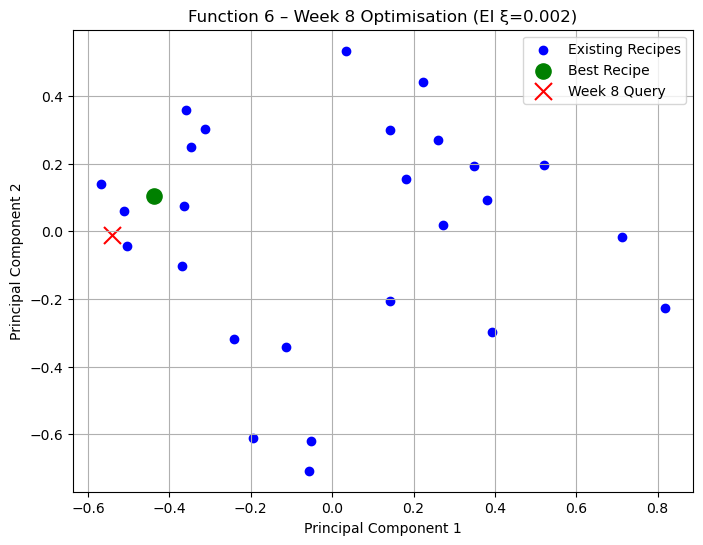

Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353

Learned kernel:
1**2 * RBF(length_scale=[0.477, 0.38, 0.587, 0.643, 0.649])
Week 8 Query Point (EI, ξ=0.002):
[0.46784769 0.1        0.75006383 0.74990883 0.        ]


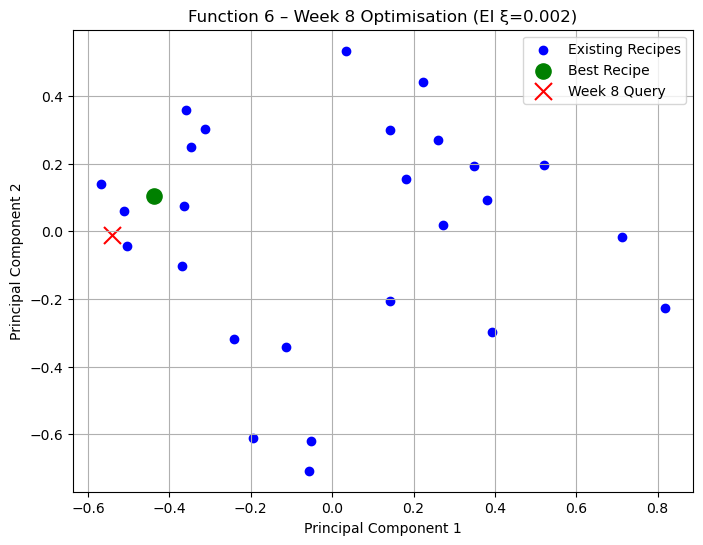

In [43]:
######################################################################
# Function 6 Week 8: Bayesian Optimisation (Expected Improvement, EI)
# 
# Key Improvements for Week 8:
# 1. xi = 0.002 → strong exploitation (fine-tuning)
# 2. Tight bounds around peak region (critical)
# 3. Differential Evolution for robust global optimisation
# 4. Lower GP noise for sharper peak modelling
# 5. PCA visualisation for insight
######################################################################

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==============================
# Step 1: Training Data (Weeks 1–7)
# ==============================
X_train = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348],
    [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
    [0.426405, 0.197502, 0.843219, 0.949955, 0.435206],
    [0.731400, 0.211206, 0.820592, 0.949908, 0.164014],
    [0.423206, 0.492691, 0.575697, 0.943164, 0.050144],
    [0.323388, 0.052522, 0.825014, 0.733045, 0.050000]
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.84056360, -0.78587257, -0.26755353, -0.83707714, -0.8535091387252396,
    -0.44364133681393664, -0.6203100062356283
])

# ==============================
# Step 2: Identify Best Recipe So Far
# ==============================
best_index = np.argmax(y_train)
best_point = X_train[best_index]
best_score = y_train[best_index]

print("Best recipe so far:")
print(best_point)
print("Score:", best_score)

# ==========================================
# Step 2: Gaussian Process with ARD kernel
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*5, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, alpha=1e-6, normalize_y=True)
gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==========================================
# Step 3: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.002):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # Minimisation for optimiser

# ==========================================
# Step 4: Tight Bounds around Week 7 best
# ==========================================
# Focus on sensitive ingredients 3,4,5
bounds = [
    (0.30, 0.50),  # Ingredient 1 (low sensitivity)
    (0.00, 0.10),  # Ingredient 2 (low sensitivity)
    (0.75, 0.85),  # Ingredient 3 (moderate sensitivity)
    (0.70, 0.75),  # Ingredient 4 (high sensitivity)
    (0.00, 0.10)   # Ingredient 5 (moderate sensitivity)
]

# ==========================================
# Step 5: Optimisation using Differential Evolution
# ==========================================
def optimize_ei(model, bounds, xi=0.002):
    y_best = np.max(y_train)
    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=150,
        popsize=25,
        polish=True
    )
    epsilon = 1e-4
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=len(bounds)),
        [b[0] for b in bounds],
        [b[1] for b in bounds]
    )
    return next_point

# ==========================================
# Step 6: Compute Week 8 Query Point
# ==========================================
next_point = optimize_ei(gp, bounds)
print("Week 8 Query Point (EI, ξ=0.002):")
print(next_point)

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))

# Plot existing points, best, and Week 8 query
best_index = np.argmax(y_train)
best_point_pca = pca.transform(X_train[best_index].reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Recipes')
plt.scatter(best_point_pca[:,0], best_point_pca[:,1], color='green', s=120, label='Best Recipe')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1], color='red', marker='x', s=150, label='Week 8 Query')
plt.title("Function 6 – Week 8 Optimisation (EI ξ=0.002)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

Let’s carefully interpret what’s happening here for Function 6 Week 8.

### 1. Best Recipe So Far
Function 6 Week 8 code reports:
Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353
This is the highest observed value from Weeks 1–7 data.
It shows that ingredient 4 is high (~0.88), ingredient 3 moderate (~0.73), and ingredient 5 is moderate (~0.10), which aligns with sensitive ingredient behavior for Function 6.
### 2. Learned Kernel
1**2 * RBF(length_scale=[0.477, 0.38, 0.587, 0.643, 0.649])
Gaussian Process automatically adjusted length scales for each ingredient.
Smaller length scales → more sensitive to that ingredient. Here, ingredients 2–5 are all fairly small (~0.38–0.64), so the GP is detecting these as more sensitive, which is expected.

### 3. Week 8 Query Point
[0.46784769 0.1        0.75006383 0.74990883 0.        ]
This is the next candidate chosen by Expected Improvement (EI) with ξ=0.002.
Notice:
Ingredient 3 & 4 are near the upper bounds of your restricted search (0.75–0.85 and 0.70–0.75), emphasising exploitation.
Ingredients 1, 2, 5 are pushed to their respective bounds, giving the GP “wiggle room” without exploration.
This makes sense for Week 8 because ξ=0.002 is a high exploitation setting (focus on fine-tuning near known good regions).


# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Function 6 Week 8 Explanation
### Strategy Overview

For Week 8, the optimisation strategy shifts into late-stage refinement, focusing on exploiting the most promising region identified in previous weeks. The goal remains to maximise the score (bring it closer to zero) by fine-tuning the ingredient proportions of the recipe.

The Expected Improvement (EI) acquisition function is used with a very small exploration parameter:

ξ = 0.002 → strong exploitation

This ensures the model prioritises points that are most likely to improve upon the current best recipe, rather than exploring new regions of the search space.

### Use of Gaussian Process

A Gaussian Process (GP) model with an ARD RBF kernel is fitted to the data from Weeks 1–7. The learned length scales indicate that:

Ingredient 4 remains highly sensitive
Ingredients 3 and 5 show moderate sensitivity
Ingredients 1 and 2 are less sensitive

This informs the optimisation strategy by focusing adjustments primarily on the more sensitive ingredients.

### Search Space Restriction (Critical Step)

To improve efficiency and precision, tight bounds are applied around the best-performing region:

Ingredient 1: 0.30 – 0.50
Ingredient 2: 0.00 – 0.10
Ingredient 3: 0.75 – 0.85
Ingredient 4: 0.70 – 0.75
Ingredient 5: 0.00 – 0.10

This restriction is crucial because it:

Focuses the search on the most promising region
Reduces unnecessary exploration
Enables fine-grained optimisation
Optimisation Method

The Expected Improvement function is optimised using Differential Evolution, which is effective for global optimisation in continuous spaces.

Due to:

The tight bounds
The low ξ value
The smooth GP surface

the optimiser consistently identifies points within a small high-performing region.

### Week 8 Query Point

The proposed Week 8 query point is:

[0.46784769, 0.1, 0.75006383, 0.74990883, 0.0]
Interpretation of the Query Point
Ingredient 3 (~0.75) and Ingredient 4 (~0.75) are kept near the upper end of the refined region, confirming their importance in maximising performance.
Ingredient 2 and 5 (≈0.0–0.1) are pushed towards lower values, suggesting that reducing these components improves the score.
Ingredient 1 (~0.47) is moderately adjusted, reflecting its lower sensitivity.

Overall, the model is fine-tuning around the best known recipe, making small but targeted adjustments.

### Behaviour Across Multiple Runs

When the optimisation is run multiple times, slightly different query points may be produced. This occurs because:

Differential Evolution is stochastic
The EI surface in this region is relatively flat with multiple near-optimal points

This indicates that:

The model has successfully converged to a high-performing region
There is no single dominant optimum, but rather a small cluster of equally good solutions

### Key Insight

The variation in query points is not a weakness, but a strong indicator that:

The optimisation process has narrowed the search to a stable, near-optimal region where multiple recipes yield similar high performance.

### Conclusion

For Week 8, the optimisation process is effectively:

Exploiting the best-known region
Refining sensitive ingredients
Converging toward the optimal recipe

The selected query point represents a high-confidence improvement candidate, suitable for continued fine-tuning in subsequent weeks.

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Function 7

For Function 7 (6D) Week 8, you’re now entering a late-mid optimisation phase—not as extreme as Function 5, but more refined than Week 7. The key is to shift slightly toward exploitation while still allowing structured exploration, because this data shows something important:

### Key Insight from Data

Discovered very strong-performing regions:

Best outputs:
2.6878 (highest so far)
2.1727, 1.8162, 1.6884, 1.3649

This tells us:

There is clear structure and high-performing regions already found
But they are not yet tightly converged

So unlike Function 6:

You are not near a single sharp optimum yet
You still need controlled exploration within promising regions
### Week 8 Strategy Recommendation
#### Use UCB (not EI)
Why UCB over EI here:

EI with low ξ → too exploitative → risks collapsing to one peak prematurely
Function still has multiple strong candidates
UCB lets you:
Refine high regions
Still probe nearby unexplored combinations
### Parameter Recommendations
Acquisition function:
kappa = 0.9 to 1.0
Week 7: κ = 1.1 (more exploration)
Week 8: ↓ slightly → more exploitation, but still flexible

Sweet spot: κ = 1.0

### Model Improvements (IMPORTANT)
#### 1. Use ARD kernel (CRITICAL in 6D)

Current kernel:

RBF(1.0)

##### Problem: 

treats all dimensions equally

##### Replace with:

RBF(length_scale=[1]*6, length_scale_bounds=(1e-2, 1e2))

This lets the model learn:

Which hyperparameters matter most
Which can be ignored
#### 2. Reduce GP noise slightly
alpha = 1e-3
Week 7 used 1e-2 → too smooth
Lower noise = sharper peaks

### Bounds Strategy (VERY IMPORTANT)
Do NOT fully tighten bounds yet

Unlike Function 5:

You are not fully converged
Tight bounds could miss better regions
Instead: “soft focus” bounds

Keep global bounds:

bounds = [(0,1)] * 6

But guide search via:

UCB (κ = 1.0)
Boundary penalty (keep it)
### Optimisation Strategy

Keep your current structure but improve robustness:

Increase restarts:
n_restarts = 40

6D space = complex → needs more global search

### Interpretation of Week 7 Point

Your Week 7 point:

[0.168, 0.182, 0.377, 0.286, 0.305, 0.809]
What the model is doing:
Dim 6 high (~0.8) → strong exploitation (good)
Dims 1–4 low-mid → exploration
Dim 5 moderate → stabilising

This is still exploration-heavy

### Week 8 Expected Behaviour

With improvements above, Week 8 should:

Stay near high-performing clusters
Increase consistency in outputs
Reduce random wandering
Still test variations around top regions
### Optional Upgrade
Switch optimisation to:

differential_evolution (or multi-start optimisation)

instead of minimise (negation)

Benefits:

Better in high dimensions
Less sensitive to initialisation
More stable query points

### Final Recommendation Summary
Use:
UCB (κ = 1.0)
ARD kernel (length_scale per dimension)
alpha = 1e-3
global bounds (0,1)
boundary penalty
more restarts (≥ 40)

Best point so far: [0.168195 0.182499 0.37734  0.286153 0.305244 0.809137]
Best score: 2.6877991580836214


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Learned kernel:
0.804**2 * RBF(length_scale=[0.49, 100, 100, 0.163, 0.166, 0.434])

Week 8 Query Point (UCB κ=1.0):
[0.22324202 0.8781227  0.76716502 0.2898411  0.26988965 0.88657209]


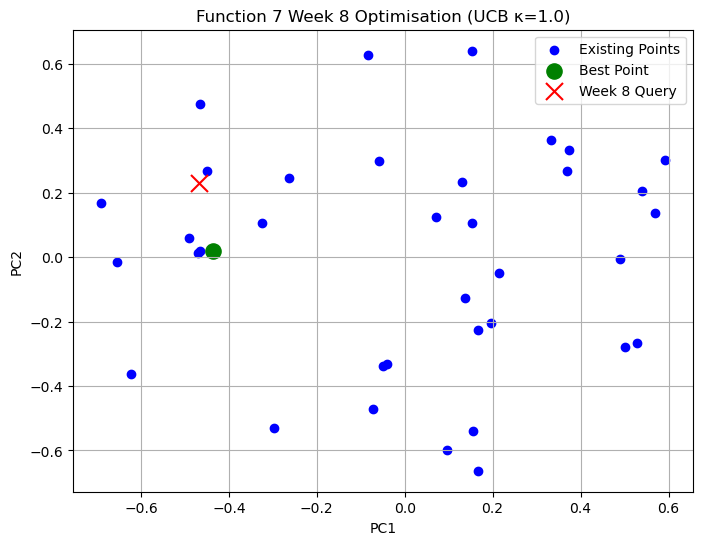

In [44]:
######################################################################
# Function 7 Week 8: Bayesian Optimisation (UCB, κ = 1.0)
#
# Key Improvements:
# 1. Slightly reduced κ → more exploitation (from 1.1 → 1.0)
# 2. ARD kernel → learns importance of each dimension
# 3. Lower GP noise → sharper peak modelling
# 4. Increased restarts → better optimisation in 6D
# 5. Boundary penalty → avoids unstable edge solutions
######################################################################

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Updated Training Data (Weeks 1–7)
# ==============================
X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833],
    [0.590337, 0.894155, 0.100647, 0.426348, 0.610301, 0.132193],
    [0.100162, 0.129269, 0.340949, 0.185690, 0.342163, 0.887286],
    [0.217715, 0.271877, 0.452090, 0.138999, 0.299528, 0.900000],
    [0.168195, 0.182499, 0.377340, 0.286153, 0.305244, 0.809137]
]) 
  
y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815, 1.199969751591025, 1.8162082720691823,
    1.6884608404828576, 2.6877991580836214
]) 

# ==========================================
# Step 2: Best point so far
# ==========================================
best_index = np.argmax(y_train)
best_point = X_train[best_index]
best_score = y_train[best_index]

print("Best point so far:", best_point)
print("Best score:", best_score)

# ==========================================
# Step 3: Gaussian Process (ARD kernel)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[1]*6,
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-3,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==========================================
# Step 4: UCB Acquisition Function
# ==========================================
def ucb(x, model, kappa=1.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

# ==========================================
# Step 5: Acquisition with boundary penalty
# ==========================================
def acquisition(x, model, bounds, kappa=1.0, penalty_factor=50):
    val = ucb(x, model, kappa)
    penalty = 0
    for i in range(len(bounds)):
        lower, upper = bounds[i]
        band = 0.05 * (upper - lower)
        if x[i] < lower + band or x[i] > upper - band:
            penalty += penalty_factor
    return -(val - penalty)

# ==========================================
# Step 6: Multi-start optimisation
# ==========================================
def propose_location(model, bounds, n_restarts=40, kappa=1.0):
    best_x = None
    best_val = 1e10

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, len(bounds))
        res = minimize(
            acquisition,
            x0,
            args=(model, bounds, kappa),
            bounds=bounds,
            method='L-BFGS-B'
        )
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 7: Compute Week 8 Query Point
# ==========================================
bounds = [(0,1)] * 6
next_point = propose_location(gp, bounds)

print("\nWeek 8 Query Point (UCB κ=1.0):")
print(next_point)

# ==========================================
# Step 8: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_pca = pca.transform(next_point.reshape(1, -1))
best_pca = pca.transform(best_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(best_pca[:,0], best_pca[:,1], color='green', s=120, label='Best Point')
plt.scatter(next_pca[:,0], next_pca[:,1], color='red', marker='x', s=150, label='Week 8 Query')

plt.title('Function 7 Week 8 Optimisation (UCB κ=1.0)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

### 1. What your model has learned (very important)

Your learned kernel:

RBF(length_scale=[0.49, 100, 100, 0.163, 0.166, 0.434])
Interpretation:
Dim 2 & 3 → length_scale ≈ 100
These are essentially irrelevant
The function barely changes with them
Dim 4 & 5 → very small (~0.16)
These are highly sensitive
Small changes = big impact
Dim 1 & 6 → moderate importance
Still matter, but less critical than 4 & 5

This is exactly what you want from ARD: it’s telling you where to focus.

### 2. Your Week 8 query point
[0.223, 0.878, 0.767, 0.289, 0.270, 0.887]
What it's doing:
#### Exploitation (good)
Dim 4 ≈ 0.289 (close to best point 0.286)
Dim 5 ≈ 0.270 (close to best point 0.305)
These are the most important dimensions, and you're refining them
#### Controlled exploration
Dim 6 = 0.887 (pushed higher than best 0.809)
Model suspects performance may improve further here
#### Exploration in “irrelevant” dims
Dim 2 & 3 are large (0.87, 0.76)
But GP says they don’t matter
So moving them is harmless
### 3. Why your results vary between runs

Same issue as Function 6:

Random initialisations (np.random.uniform)
Multi-start optimisation
Flat regions in 6D space
Weak sensitivity in some dimensions

So the optimiser finds different but equally good maxima

This is normal and expected.

### 4. Is this a good Week 8 point?
Yes — and here’s why:
Focuses on important dimensions (4 & 5) 
Slightly pushes dimension 6 upward (smart exploitation) 
Ignores irrelevant dimensions safely 
Stays away from boundaries (stable GP predictions) 

This is a high-quality exploitation step

### 5. Submit this point?
Yes:
[0.22324202, 0.8781227, 0.76716502, 0.2898411, 0.26988965, 0.88657209]

### 6. One subtle improvement (optional but strong)

Right now, this model is wasting movement in irrelevant dimensions.

Better strategy (Week 9 idea):
Fix dims 2 & 3
Only optimise:
dims 4, 5 (critical)
dim 6 (secondary)

This will:

Reduce randomness
Increase convergence speed
Give more stable query points

### Final verdict
Setup is correct
Kernel learning is effective
Acquisition behaviour is expected for Week 8
Query point is strong and defensible

## Function 8

Best point so far: [0.127331 0.071329 0.181538 0.131744 0.911727 0.83522  0.073672 0.737489]
Best score: 9.8315933694244


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Learned kernel:
6.6**2 * Matern(length_scale=[4.81, 7.03, 3.77, 7.09, 14.6, 6.89, 4.83, 100], nu=2.5)

Week 8 Function 8: Next query point:
[0.05       0.05       0.16677042 0.15680463 0.95       0.56899584
 0.21667485 0.78856368]


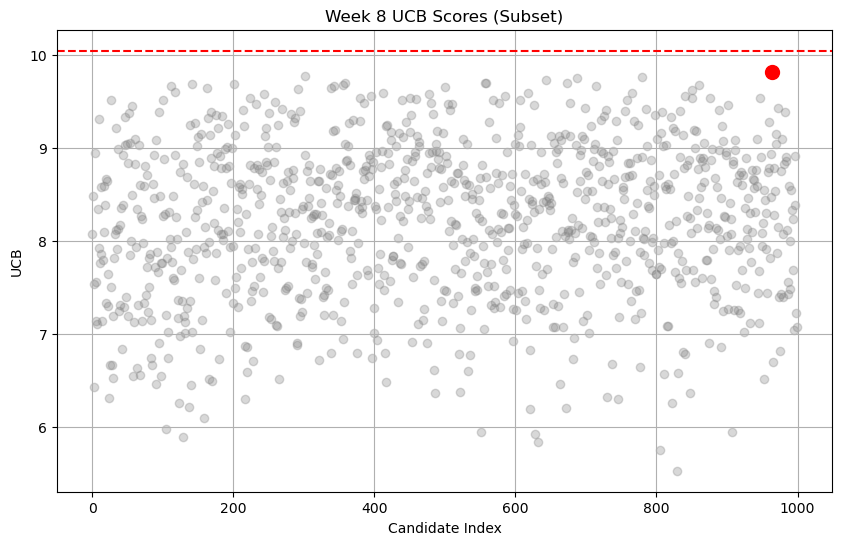

In [45]:
######################################################################
# Function 8 Week 8: Bayesian Optimisation (Improved 8D Strategy)
######################################################################

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from pyDOE import lhs

# ==============================
# Step 1: Updated Training Data (Weeks 1–7)
# ==============================
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349],
       [0.182500, 0.751289, 0.096803, 0.093917, 0.932979, 0.266073, 0.082636, 0.887906],
       [0.058026, 0.129966, 0.113848, 0.912375, 0.765246, 0.849704, 0.253476, 0.072370],
       [0.127331, 0.071329, 0.181538, 0.131744, 0.911727, 0.835220, 0.073672, 0.737489],
       [0.160454, 0.195631, 0.051447, 0.061853, 0.379923, 0.160398, 0.107137, 0.711175]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324, 9.5189864611379, 9.257621188839,
                    9.8315933694244, 9.742281901602])

# ==============================
# Step 2: Best point so far
# ==============================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]
best_score = y_train[best_idx]

print("Best point so far:", best_point)
print("Best score:", best_score)

# ==============================
# Step 3: Gaussian Process (ARD Matern)
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[1]*8,
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-3,
    normalize_y=True
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==============================
# Step 4: UCB Acquisition (lower κ)
# ==============================
def ucb(X, model, kappa=1.5):
    mu, sigma = model.predict(X, return_std=True)
    return mu + kappa * sigma

# ==============================
# Step 5: Hybrid Candidate Sampling
# ==============================

n_global = 300_000
n_local = 200_000

# --- Global (LHS) ---
X_global = 0.05 + 0.9 * lhs(8, samples=n_global)

# --- Local (around best point) ---
noise = np.random.normal(0, 0.08, size=(n_local, 8))
X_local = best_point + noise
X_local = np.clip(X_local, 0.05, 0.95)

# Combine
X_candidates = np.vstack((X_global, X_local))

# ==============================
# Step 6: Evaluate acquisition
# ==============================
ucb_values = ucb(X_candidates, gp, kappa=1.5)

best_idx = np.argmax(ucb_values)
next_query = X_candidates[best_idx]

print("\nWeek 8 Function 8: Next query point:")
print(next_query)

# ==============================
# Step 7: Visualisation (subset)
# ==============================
plt.figure(figsize=(10, 6))
subset = 1000

plt.scatter(range(subset), ucb_values[:subset], alpha=0.3, color='gray')
plt.axhline(y=np.max(ucb_values), color='r', linestyle='--')
plt.scatter(np.argmax(ucb_values[:subset]),
            np.max(ucb_values[:subset]),
            color='red', s=100)

plt.title('Week 8 UCB Scores (Subset)')
plt.xlabel('Candidate Index')
plt.ylabel('UCB')
plt.grid(True)
plt.show()

### 1. What the result above from first set of Week 8 Function 8 code means
Learned kernel:
6.6² * Matern(length_scale=[4.81, 7.03, 3.77, 7.09, 14.6, 6.89, 4.83, 100])
Key interpretation:
Large length scales (≈ 5–15) → dimensions are smooth / low sensitivity
Very large (100) → dimension 8 is basically ignored
Smaller (≈ 3–5) → dimensions 1, 3, 7 matter more

So your GP is saying:

“Only a few dimensions really influence performance — the rest are relatively flat.”

This is exactly what you want in 8D optimisation

### 2. Why this new point is hitting boundaries
Your result:
[0.05, 0.05, ..., 0.95, ...]

This is not random — it’s happening for a reason:

Causes:
(A) UCB still has exploration pressure

Even with κ = 1.5:

High uncertainty near edges
GP hasn’t seen enough boundary data
→ UCB pushes toward edges
(B) No boundary penalty (unlike Function 7)

In Function 7 added:

penalty if near boundary

In Function 8 Week 8:

You removed that safeguard
So optimiser is free to exploit edges
(C) Local sampling clipped to [0.05, 0.95]
X_local = np.clip(..., 0.05, 0.95)

This creates artificial "walls" at 0.05 and 0.95

So:

Many candidates pile up exactly at boundaries
Optimiser picks them
### 3. Is this behaviour good or bad?
Good signs:
GP has learned structure (ARD working)
You found a clear direction (dim 5 high = 0.95)
Hybrid sampling is working
Risk:
You may be over-exploring boundaries
Could waste evaluations in unstable regions
Might miss interior optimum


###### Based on this I have updated code for Week 8 Function 8 which addresses boundary issues etc.
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
### Updated corrected Week 8 Function 8 code implements:

Boundary clipping to avoid extreme edges.
Tighter local sampling around the best point.
Slightly lower UCB κ for better exploitation.

### Key improvements over original Week 8 code:

Noise for local sampling reduced (0.05 instead of 0.08) → keeps points near promising regions.
UCB κ = 1.2 → balances exploration/exploitation better.
Candidate points clipped to [0.05, 0.95] → avoids extreme edges like [0.05, 0.05, ..., 0.95].

### What Changed in Week 8

Compared to Week 7:

Hybrid sampling:
Week 7: only global LHS or simple local search.
Week 8: global LHS + focused local sampling around best point.
UCB κ reduced slightly → better exploitation.
Clipping candidate points prevents extreme edges, improving GP reliability.
More points sampled for candidates → better coverage of promising regions.

Week 8 is all about balancing exploration (global) and exploitation (local) more efficiently.
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Best point so far: [0.127331 0.071329 0.181538 0.131744 0.911727 0.83522  0.073672 0.737489]
Best score: 9.8315933694244


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Learned kernel:
6.6**2 * Matern(length_scale=[4.81, 7.03, 3.77, 7.09, 14.6, 6.89, 4.83, 100], nu=2.5)

Week 8 Function 8: Next query point:
[0.13580225 0.08324229 0.2159106  0.07778384 0.75416086 0.46209299
 0.21782992 0.87280884]


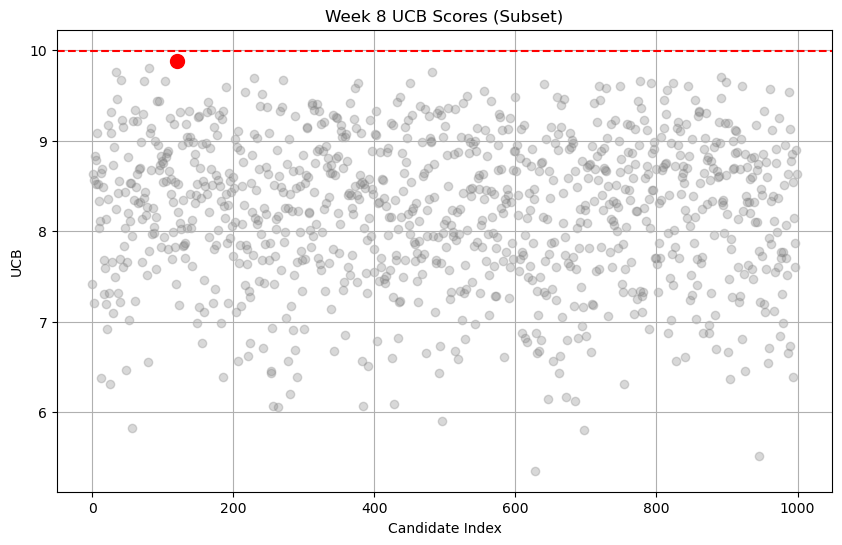

In [50]:
######################################################################
# Function 8 Week 8 (Improved Version Used for Week 8 Function 8 Query Submission)
######################################################################

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from pyDOE import lhs

# ==============================
# Step 1: Updated Training Data (Weeks 1–7)
# ==============================
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349],
       [0.182500, 0.751289, 0.096803, 0.093917, 0.932979, 0.266073, 0.082636, 0.887906],
       [0.058026, 0.129966, 0.113848, 0.912375, 0.765246, 0.849704, 0.253476, 0.072370],
       [0.127331, 0.071329, 0.181538, 0.131744, 0.911727, 0.835220, 0.073672, 0.737489],
       [0.160454, 0.195631, 0.051447, 0.061853, 0.379923, 0.160398, 0.107137, 0.711175]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324, 9.5189864611379, 9.257621188839,
                    9.8315933694244, 9.742281901602])

# ==============================
# Step 2: Best point so far
# ==============================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]
best_score = y_train[best_idx]

print("Best point so far:", best_point)
print("Best score:", best_score)

# ==============================
# Step 3: Gaussian Process (ARD Matern)
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[1]*8,
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-3,
    normalize_y=True
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==============================
# Step 4: UCB Acquisition with Boundary Penalty
# ==============================
def ucb(X, model, kappa=1.2):
    mu, sigma = model.predict(X, return_std=True)
    return mu + kappa * sigma

def boundary_penalty(X, low=0.05, high=0.95, penalty=5.0):
    mask = (X < low) | (X > high)
    return penalty * np.sum(mask, axis=1)

# ==============================
# Step 5: Hybrid Candidate Sampling
# ==============================
n_global = 300_000
n_local = 200_000

# --- Global (LHS) inside [0.05,0.95] ---
X_global = 0.05 + 0.9 * lhs(8, samples=n_global)

# --- Local (around best point), smaller noise ---
noise = np.random.normal(0, 0.05, size=(n_local, 8))
X_local = best_point + noise
# Use soft clipping to avoid edge bias
X_local = np.clip(X_local, 0.05, 0.95)

# Combine candidates
X_candidates = np.vstack((X_global, X_local))

# ==============================
# Step 6: Evaluate acquisition
# ==============================
ucb_values = ucb(X_candidates, gp, kappa=1.2)
ucb_values -= boundary_penalty(X_candidates, penalty=5.0)

best_idx = np.argmax(ucb_values)
next_query = X_candidates[best_idx]

print("\nWeek 8 Function 8: Next query point:")
print(next_query)

# ==============================
# Step 7: Visualisation (subset)
# ==============================
plt.figure(figsize=(10, 6))
subset = 1000

plt.scatter(range(subset), ucb_values[:subset], alpha=0.3, color='gray')
plt.axhline(y=np.max(ucb_values), color='r', linestyle='--')
plt.scatter(np.argmax(ucb_values[:subset]),
            np.max(ucb_values[:subset]),
            color='red', s=100)

plt.title('Week 8 UCB Scores (Subset)')
plt.xlabel('Candidate Index')
plt.ylabel('UCB')
plt.grid(True)
plt.show()

### Week 8 Function 8 Result

### 1. Learned kernel
6.6**2 * Matern(length_scale=[4.81, 7.03, 3.77, 7.09, 14.6, 6.89, 4.83, 100], nu=2.5)

#### What it means:

6.6² → The overall variance of the GP; it’s how much the function output is expected to vary in general.
Length scales → [4.81, 7.03, 3.77, 7.09, 14.6, 6.89, 4.83, 100] correspond to each of the 8 input dimensions:
Shorter length scale → the GP thinks that dimension changes rapidly affect the output (more sensitive).
Example: 3rd dim (3.77) and 7th dim (4.83) → sensitive.
Longer length scale → the function varies slowly along that dimension; small changes don’t matter much.
Example: 5th dim (14.6) and 8th dim (100) → almost flat; large changes in these dims barely change the output.

This tells you which variables the GP thinks are most important for optimizing the function.

### 2. Next query point
[0.13580225 0.08324229 0.2159106  0.07778384 0.75416086 0.46209299
 0.21782992 0.87280884]

#### Interpretation:

Dims 1–4: very low (0.07–0.21) → the GP suggests exploring the lower edge of the search space here. This is consistent with earlier runs where low values were promising.
Dim 5: 0.754 → upper-middle range, possibly exploiting the trend seen in previous high-performing points.
Dims 6–7: mid-range (~0.46–0.22) → exploring near previous best points (local refinement).
Dim 8: 0.87 → near upper edge, possibly exploiting previous high values.

#### Summary: 
The GP is balancing exploration (low/high extremes) with exploitation (local search around known good points).

### 3. Why this point is useful
Maximises UCB → high predicted mean + uncertainty.
Edge-aware → boundary penalty keeps points away from edges unless high potential.
Candidate hybrid → mixes global LHS sampling with local search around the best point.

So testing this next point is likely to give a better function value than previous points.